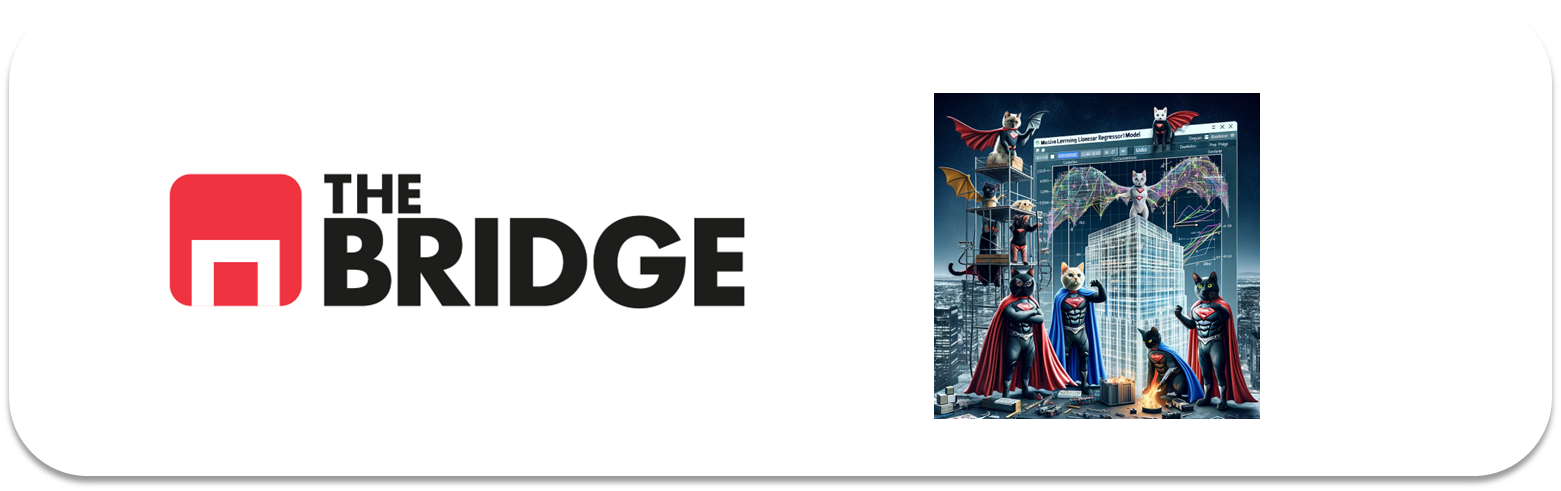

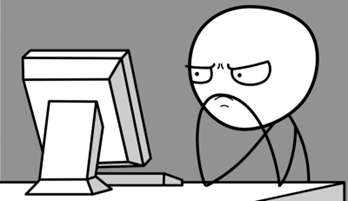

Para ejercitarte y afianzar lo aprendido sobre **Regresión Logística para clasificación binaria**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios).

### Inicio: Entendiendo el problema

En este caso el objetivo de los ejercicios es hacer un modelado de regresión logística sobre el dataset conocidos como "Adults" o "Census Income" que permita casificar a las personas en si ganan más de 50K dolalres o no, en función de una serie de características demográficas y de empleo. Sigue las instrucciones cuando sea necesario para poder continuar

El nombre de las columnas y sus valores se muestra a continuación (las columnas siguen el mismo orden que en el fichero, por si tuvieras que utilizar estos nombres)

age: edad, continuous.  

workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.  

fnlwgt: continuous (a eliminar)  

education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.  

education-num: continuous.  

marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.  

occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.

relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.  

race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.  

sex: Female, Male.  

capital-gain: continuous.  

capital-loss: continuous.  

hours-per-week: continuous.  

native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.  


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [121]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score, confusion_matrix

### Ejercicio 1: Carga de datos y vistazo


Carga el conjunto de datos de TRAIN ("./data/adult.data") en un dataframe (tendrás que explorar el tipo de archivo y darle nombre a las columnas). Muestra la descripción de los datos y las primeras filas del conjunto de datos.

*Cargamos los datos, que es un poco tricky*

In [122]:


# Aunque la extensión no es csv los datos tienen ese formato (así vamos recordando cosas del pasado): 
# es un archvivo de texto separado por comas. Como no tiene cabecera, se lo expresamos así

adult_df = pd.read_csv('./data/adult.data', header=None)

# Nombres de las columnas, según la descripción del conjunto de datos
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
                'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
                'hours_per_week', 'native_country', 'income']

adult_df.columns = column_names


*Hacemos el info y el head*

In [123]:
print(adult_df.info())
adult_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
None


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Ejercicio 2: Preparación y limpieza de Datos (I)

En una situación normal tendríamos que revisar el dataset para ver qué podemos limpiar (convertir tipos, cambiar valores raros, etc) y sólo no deberíamos imputar faltantes sobre el dataset global. Aquí te dirigiré los pasos:

1. Quita los espacios iniciales y finales de todos los valores string del dataset.
2. Comprueba que 'workclass', 'occupation', 'native_country' contienen un valor "raro", que indica los faltantes (este es un ejemplo de dataset con "missing" que no están marcados por np.NaN)
3. Deshazte de las columna "fnlwgt" que ni se entiende, ni se necesita y deshazte de las filas con esos faltantes (tenemos muchos datos y poco "tiempo").

*1*

*Va siendo hora de desempolvar nuestros conocimientos de pandas y aplicar los métodos de string de pandas, otra vez, que ya lo hicimos en varios ejercicios*  
*IMPORTANTE: Mientras no analicemos valores, ni los cambiemos por valores que salgan de agregar otros o en función de agregaciones de otros, podemos manipular el dataset original. PERO además en este caso podríamos hacer cualquier cosa porque es el dataset de TRAIN, tal y como lo especifíca en el enunciado del ejercicio 1*

In [124]:
# Metodo manual
# del info() vemos las columnas que son tipo "object"
col_str = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']
for col in col_str:
    adult_df[col] = adult_df[col].str.strip()

In [125]:
# Método sofisticado (observa que usamos el método select_dtypes para quedarnos solo con las columnas tipo "object")

col_str = adult_df.select_dtypes(include=['object', 'str']).columns
adult_df[col_str] = adult_df[col_str].apply(lambda col: col.str.strip())

*2*

*Veamos esos valores que nos dicen que pueden ser raros*

In [126]:
col_raros = ['workclass', 'occupation', 'native_country']

for col in col_raros:
    print(f"Para {col}")
    print("\n".join(adult_df[col].unique()))
    print("\n\n")


Para workclass
State-gov
Self-emp-not-inc
Private
Federal-gov
Local-gov
?
Self-emp-inc
Without-pay
Never-worked



Para occupation
Adm-clerical
Exec-managerial
Handlers-cleaners
Prof-specialty
Other-service
Sales
Craft-repair
Transport-moving
Farming-fishing
Machine-op-inspct
Tech-support
?
Protective-serv
Armed-Forces
Priv-house-serv



Para native_country
United-States
Cuba
Jamaica
India
?
Mexico
South
Puerto-Rico
Honduras
England
Canada
Germany
Iran
Philippines
Italy
Poland
Columbia
Cambodia
Thailand
Ecuador
Laos
Taiwan
Haiti
Portugal
Dominican-Republic
El-Salvador
France
Guatemala
China
Japan
Yugoslavia
Peru
Outlying-US(Guam-USVI-etc)
Scotland
Trinadad&Tobago
Greece
Nicaragua
Vietnam
Hong
Ireland
Hungary
Holand-Netherlands





*Hay un "?" que parece que no casa con el resto de valores, es nuestra forma de indicar "missing" o "faltante" o "desconocido"*

*3*

*Primero de fnlwgt*

In [127]:
adult_df.drop("fnlwgt", axis = 1, inplace = True)

In [128]:
# Forma 1, larga:
son_raros = None
for i,col in enumerate(col_raros):
    subcondicion = adult_df[col] == "?"
    if i == 0:
        condicion = subcondicion
    else:
        condicion = condicion | subcondicion # Importante son las filas que cumplen tener uno de los posibles valores raros por eso el "or" de Series -> "|""

print(len(adult_df[condicion]))
adult_df = adult_df.loc[condicion == False].copy()

2399


In [129]:
# Forma 2, corta
adult_df = adult_df.replace('?', np.nan).dropna()

In [130]:
adult_df.native_country.value_counts()

native_country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
India                           100
El-Salvador                     100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Poland                           56
Columbia                         56
Iran                             42
Taiwan                           42
Haiti                            42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece                           29
Ecuador      

### Ejercicio 3: Preparación y limpieza de Datos (II)

Muestra el reparto de valores de "native-country". Convierte la variable en una binara con 1 para ciudadanos estadounidenses y 0 para el resto.

NOTA: En otras ocasiones lo hubieramos tratados por continentes por ejemplo, pero de primeras la diferencia de distribución es tan alta que es mejor simplificar que no quedarse con todos los valores

In [131]:
# Opción 1: Con lo que hemos visto
adult_df["native_country_bin"] = adult_df["native_country"].str.replace("United-States","1")
adult_df.loc[adult_df["native_country_bin"] != "1", "native_country_bin"] = "0"
adult_df["native_country_bin"] = adult_df["native_country_bin"].astype("int")
adult_df.drop("native_country", axis = 1, inplace = True) # Nos deshacemos de "native_country" después de "codificarla", tanto del dataframe
col_str = [col for col in col_str if col != "native_country"] # como de la lista de columnas tipo str

In [132]:
adult_df["native_country_bin"].value_counts()

native_country_bin
1    27504
0     2658
Name: count, dtype: int64

### Ejercicio 4: Preparación y limpieza de Datos (III)

Escoge la variable target, ¿qué particularidad tiene?¿qué debemos hacer con ella? Hazlo.

*Observemos los valores que puede tener*

In [133]:
adult_df["income"].value_counts()

income
<=50K    22654
>50K      7508
Name: count, dtype: int64

*Es categórica pura (con etiquetas), como ya esperábamos del ejercicio anterior y por el hecho de que nos dicen desde el principio que es un problema de clasificación. Tendremos que convertirla a un numero, podemos hacer un ordinal enconding a mano o a máquina, el que prefieras*

In [134]:
adult_df['income'] = adult_df['income'].map({'<=50K': 0, '>50K': 1})

print(adult_df['income'].value_counts())

income
0    22654
1     7508
Name: count, dtype: int64


In [135]:
# adult_df['income'] = (adult_df['income'] == '>50K').astype(int)

*Es un dataset desbalanceado, lo cual nos afectará para elegir la métrica y además deberíamos tratarlo de alguna forma como veremos en unidades posteriores*

### Ejercicio 5: Preparar variables categóricas (I)

Prepara las variables categóricas, salvo "education" y "native_country" (o su equivalente si no la has llamado así al connvertirla en binaria), convirtiéndolas con un one-hot encoding (usa el pd.get_dummies). NOTA: Recuerda que este es el dataset de train, por eso lo atacamos directamente.

In [136]:
# Cuidado,solo debemos incluir las CATEGORICAS del dataset, y NO DEBEMOS INCLUIR EL TARGET


In [137]:
adult_df

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,income,native_country_bin
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,0,1
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,0,1
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,0,1
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,0,1
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,0,1
32557,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,1,1
32558,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,0,1
32559,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,0,1


In [138]:
adult_df = pd.get_dummies(
    adult_df, 
    columns=[col for col in col_str if col not in ['education', 'income']], 
    dtype=int
)

### Ejercicio 6: Preparar variables categóricas (II)

Codifica la variable "education" usando un ordinal encoding, no uses la codificación por defecto, elígela tú y razónala o bien demuestra pillería y que has revisado el dataset.

*Este es el orden teniendo en cuenta el grado de escolarización:o sea a lo bruto*

    Preschool
    1st-4th
    5th-6th
    7th-8th
    9th
    10th
    11th
    12th
    HS-grad (Graduado de Educación Secundaria)
    Some-college (Alguna educación universitaria, sin título)
    Assoc-voc (Título asociado - educación vocacional)
    Assoc-acdm (Título asociado - académico)
    Bachelors (Licenciatura o título universitario)
    Masters (Maestría)
    Prof-school (Escuela profesional, educación después de la licenciatura, como derecho o medicina)
    Doctorate (Doctorado)



In [139]:
categories = [[
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate"
]]


In [140]:
# usa un ordinal encoder

categories = [
    "Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
    "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
    "Prof-school", "Doctorate"
]

adult_df["education"] = pd.Categorical(adult_df["education"], categories=categories, ordered=True)
adult_df["education"] = adult_df["education"].cat.codes

if "education" in col_str: 
    col_str.remove("education")

In [141]:
adult_df["education"].value_counts()

education
8     9840
9     6678
12    5044
13    1627
10    1307
6     1048
11    1008
5      820
3      557
14     542
4      455
7      377
15     375
2      288
1      151
0       45
Name: count, dtype: int64

*Otra posibilidad es directamente deshacernos de "education" y quedarnos con eduaction_num*

In [142]:
adult_df.drop("education", axis=1, inplace=True)

if "education" in col_str:
    col_str.remove("education")

NOTA: En un ejercicio completo deberíamos decidir si escalar las variables numéricas continuas, si quieres puedes hacero tú como extra y comparar con el modelo que vamos a completar en este conjunto de ejercicios.

### Ejercicio 7: Modelo (I)

Instancia el modelo de regresión logística, con el hiperparámetro "max_iter" a 10000.

In [143]:
# usa un solver 'newton-cholesky'

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=10000, solver='newton-cholesky')

### Ejercicio 8: Entrenamiento

Entrena modelo para el dataset de train tal como lo hemos preparado, creando antes el dataset sólo de features (X_train) y la serie con los valores del target (y_train). NOTA: Deshazte de "education_num" si has codificado tú a mano "education".

In [144]:
X_train = adult_df.drop(columns=['income', 'education_num'])
y_train = adult_df['income']

In [145]:
# entrena la regresión logística

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Ejercicio 9: Evaluación (I)

Previo a la evaluación necesitamos obtener y preparar el dataset de test. Carga el dataset a partir de "./data/adult.test". Luego aplícale las mismas operaciones que has realizado sobre el train. (NOTA; Puede que tengas que cambiar alguna cosa en la variable "income" para convertirla)

In [146]:
adult_test_df = pd.read_csv("./data/adult.test", header = None)
adult_test_df.columns = column_names
col_str = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']
for col in col_str:
    print(col)
    adult_test_df[col] = adult_test_df[col].str.strip()
adult_test_df.drop("fnlwgt", axis = 1, inplace = True)
son_raros = None
for i,col in enumerate(col_raros):
    subcondicion = adult_test_df[col] == "?"
    if i == 0:
        condicion = subcondicion
    else:
        condicion = condicion | subcondicion # Importante son las filas que cumplen tener uno de los posibles valores raros por eso el "or" de Series -> "|""

print(len(adult_test_df[condicion]))
adult_test_df = adult_test_df.loc[condicion == False].copy()
adult_test_df["native_country_bin"] = adult_test_df["native_country"].str.replace("United-States","1")
adult_test_df.loc[adult_test_df["native_country_bin"] != "1", "native_country_bin"] = "0"
adult_test_df["native_country_bin"] = adult_test_df["native_country_bin"].astype("int")
adult_test_df.drop("native_country", axis = 1, inplace = True)
col_str.remove("native_country")
adult_test_df["income"] = adult_test_df['income'].str.replace(">50K.","1").replace("<=50K","0").replace("<=50K.","0").astype(int)
adult_test_df.drop("education", axis = 1, inplace = True)
adult_test_df = pd.get_dummies(adult_test_df, columns = [col for col in col_str if col != "education" and col  != "income"], dtype= "int") 
X_test = adult_test_df.drop("income", axis = 1)
y_test = adult_test_df["income"]

workclass
education
marital_status
occupation
relationship
race
sex
native_country
income
1221


### Ejercicio 10: Evaluación (II)

Obten la predicción para X_train y para X_test.

In [147]:
# 1. Asegurarse de que 'education_num' no esté en el test
if "education_num" in X_test.columns:
    X_test = X_test.drop(columns=["education_num"])

# 2. Alinear las columnas de test con las de train (¡muy importante!)
# Esto evita errores si get_dummies creó columnas distintas en train y test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 3. Realizar predicciones
pred_train = log_model.predict(X_train)
pred_test = log_model.predict(X_test)



### Ejercicio 11: Evaluación (III)

Muestra la matriz de confusión para los resultados de train, así como el clasification_report de sklearn

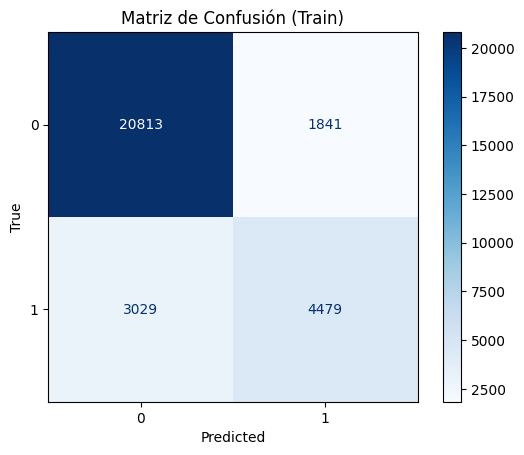

              precision    recall  f1-score   support

           0       0.87      0.92      0.90     22654
           1       0.71      0.60      0.65      7508

    accuracy                           0.84     30162
   macro avg       0.79      0.76      0.77     30162
weighted avg       0.83      0.84      0.83     30162



In [148]:
# Calcular la matriz de confusión
# IMPORTANTE: Usamos 'log_model' que es como lo llamamos al entrenarlo
pred_train = log_model.predict(X_train)
conf_matrix = confusion_matrix(y_train, pred_train)

# Visualizar la matriz de confusión
ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot(cmap='Blues')
plt.title('Matriz de Confusión (Train)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Generar el informe de clasificación
print(classification_report(y_train, pred_train))

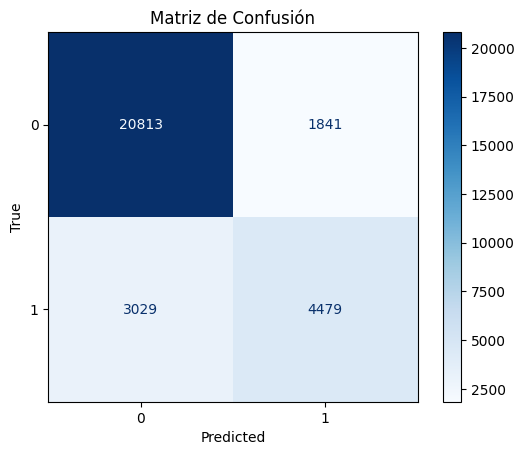

              precision    recall  f1-score   support

           0       0.87      0.92      0.90     22654
           1       0.71      0.60      0.65      7508

    accuracy                           0.84     30162
   macro avg       0.79      0.76      0.77     30162
weighted avg       0.83      0.84      0.83     30162



In [ ]:
# Calcular la matriz de confusión
pred_train = log_model.predict(X_train)
conf_matrix = confusion_matrix(y_train, pred_train)

# Visualizar la matriz de confusión
ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Generar el informe de clasificación
print(classification_report(y_train, pred_train))


In [150]:
# Empleando las capacidades nativas de Sklearn



### Ejercicio 12: Evaluación (IV)
Muestra la matriz de confusión y el classification report para los resultados del test. Comparála con los de train.

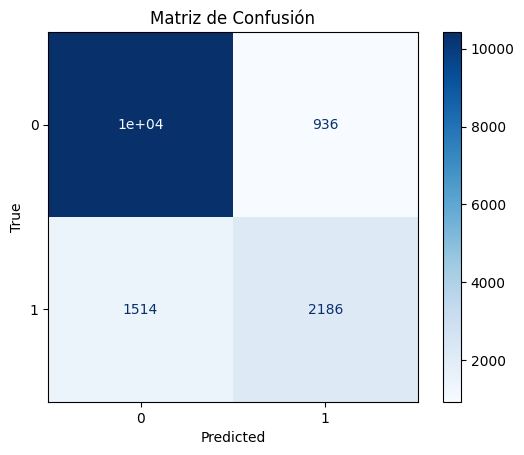

              precision    recall  f1-score   support

           0       0.87      0.92      0.89     11360
           1       0.70      0.59      0.64      3700

    accuracy                           0.84     15060
   macro avg       0.79      0.75      0.77     15060
weighted avg       0.83      0.84      0.83     15060



In [154]:
# Calcular la matriz de confusión
pred_test = log_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, pred_test)

# Visualizar la matriz de confusión
ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Generar el informe de clasificación
print(classification_report(y_test, pred_test))

*El modelo, como era de esperar, detecta mejor la clase 0 (muy superior a la 1 en proporcion) pero muestra buenos números para la clase 1. Además la generalización es casi perfecta. Podriamos decir que tenemos un modelo muy bueno*

### Extra: 

1. Muestra la curva ROC de test.

2. Muestra los coeficientes y su importancia.

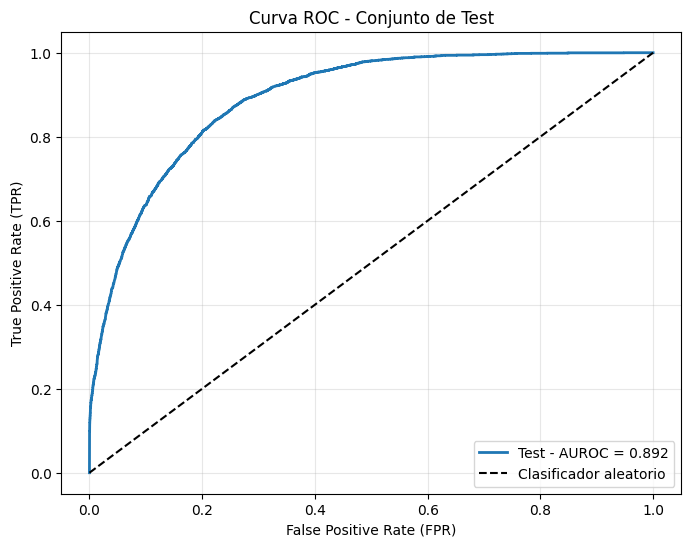

AUROC del conjunto de test: 0.8918


In [156]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtener las probabilidades predichas para el conjunto de test
y_pred_proba_test = log_model.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_pred_proba_test)

# Calcular el AUROC
auroc_test = roc_auc_score(y_test, y_pred_proba_test)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, label=f'Test - AUROC = {auroc_test:.3f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Conjunto de Test')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUROC del conjunto de test: {auroc_test:.4f}")

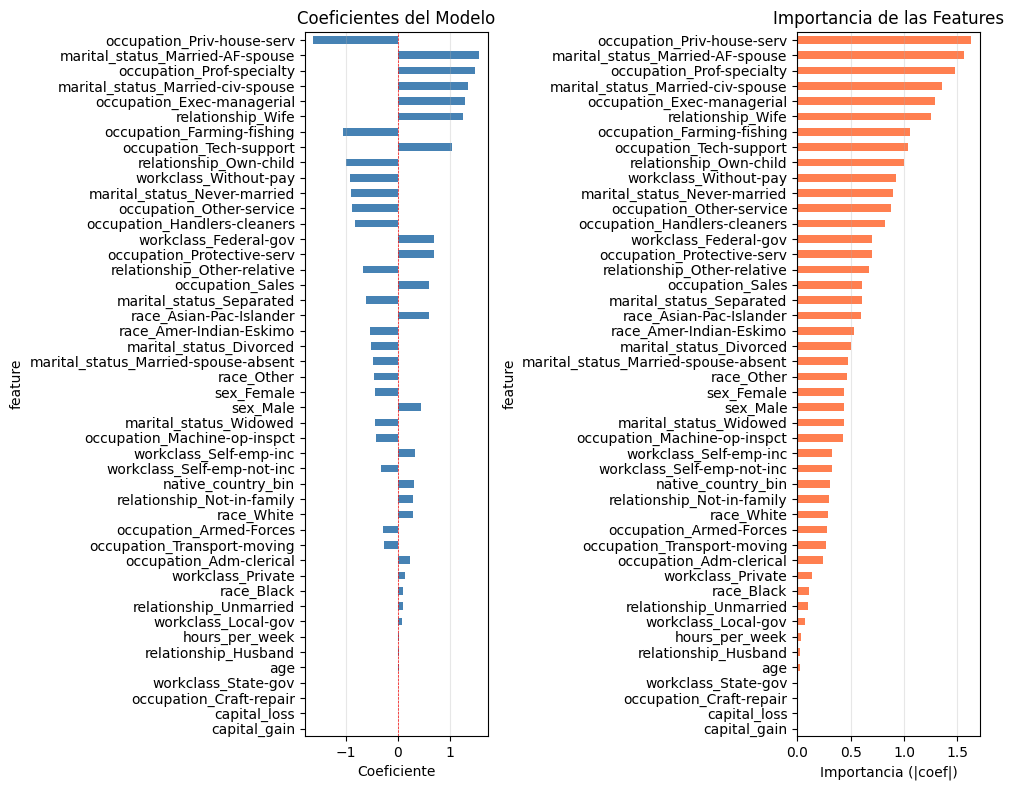


Top 10 features más importantes:
                          feature      coef  importance
       occupation_Priv-house-serv -1.631088    1.631088
 marital_status_Married-AF-spouse  1.566278    1.566278
        occupation_Prof-specialty  1.481705    1.481705
marital_status_Married-civ-spouse  1.354787    1.354787
       occupation_Exec-managerial  1.293523    1.293523
                relationship_Wife  1.252141    1.252141
       occupation_Farming-fishing -1.060155    1.060155
          occupation_Tech-support  1.036803    1.036803
           relationship_Own-child -0.999586    0.999586
            workclass_Without-pay -0.921908    0.921908

Top 10 features con coeficientes más negativos:
                     feature      coef  importance
  occupation_Priv-house-serv -1.631088    1.631088
  occupation_Farming-fishing -1.060155    1.060155
      relationship_Own-child -0.999586    0.999586
       workclass_Without-pay -0.921908    0.921908
marital_status_Never-married -0.897766    0.89

In [158]:
import pandas as pd
import numpy as np

# Función para mostrar coeficientes del modelo
def show_coefs(model, figsize=(10, 8)):
    """
    Muestra los coeficientes del modelo de regresión logística
    """
    # Crear DataFrame con los coeficientes
    df_coef = pd.DataFrame({
        'feature': model.feature_names_in_,
        'coef': model.coef_[0]
    })
    
    # Calcular importancia (valor absoluto de los coeficientes)
    df_coef['importance'] = df_coef['coef'].abs()
    
    # Ordenar por importancia para el gráfico
    df_coef_sorted = df_coef.sort_values('importance', ascending=True)
    
    # Gráfico de coeficientes
    fig, ax = plt.subplots(1, 2, figsize=figsize)
    
    # Gráfico 1: Coeficientes con signo
    df_coef_sorted.plot(kind='barh', x='feature', y='coef', ax=ax[0], legend=False, color='steelblue')
    ax[0].axvline(x=0, color='red', linestyle='--', linewidth=0.5)
    ax[0].set_xlabel('Coeficiente')
    ax[0].set_title('Coeficientes del Modelo')
    ax[0].grid(axis='x', alpha=0.3)
    
    # Gráfico 2: Importancia (valor absoluto)
    df_coef_sorted.plot(kind='barh', x='feature', y='importance', ax=ax[1], legend=False, color='coral')
    ax[1].set_xlabel('Importancia (|coef|)')
    ax[1].set_title('Importancia de las Features')
    ax[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar tabla con los coeficientes más importantes
    print("\nTop 10 features más importantes:")
    print(df_coef.sort_values('importance', ascending=False).head(10).to_string(index=False))
    
    print("\nTop 10 features con coeficientes más negativos:")
    print(df_coef.sort_values('coef').head(10).to_string(index=False))
    
    return df_coef

# Mostrar coeficientes del modelo entrenado
df_coefs = show_coefs(log_model)

*Como era de esperar el modelo presenta un magnífico AuROC = 0.9 y una figura ROC de las que no verás muchas*

In [159]:
def show_coefs(model, figsize=(10, 5)):
    df_coef = pd.DataFrame(model.coef_[0], index=model.feature_names_in_, columns=["coefs"])

    fig, ax = plt.subplots(1, 2, figsize=figsize)
    df_coef.plot(kind="barh", ax=ax[0], legend=False)
    df_coef.abs().sort_values(by="coefs").plot(kind="barh", ax=ax[1], legend=False)
    fig.suptitle("Model Coefficients")

    fig.tight_layout()

    return df_coef

,coefs
age,0.022237
capital_gain,0.000319
capital_loss,0.000664
hours_per_week,0.031753
native_country_bin,0.309717
workclass_Federal-gov,0.704860
workclass_Local-gov,0.071134
workclass_Private,0.134369
workclass_Self-emp-inc,0.328979
workclass_Self-emp-not-inc,-0.324614


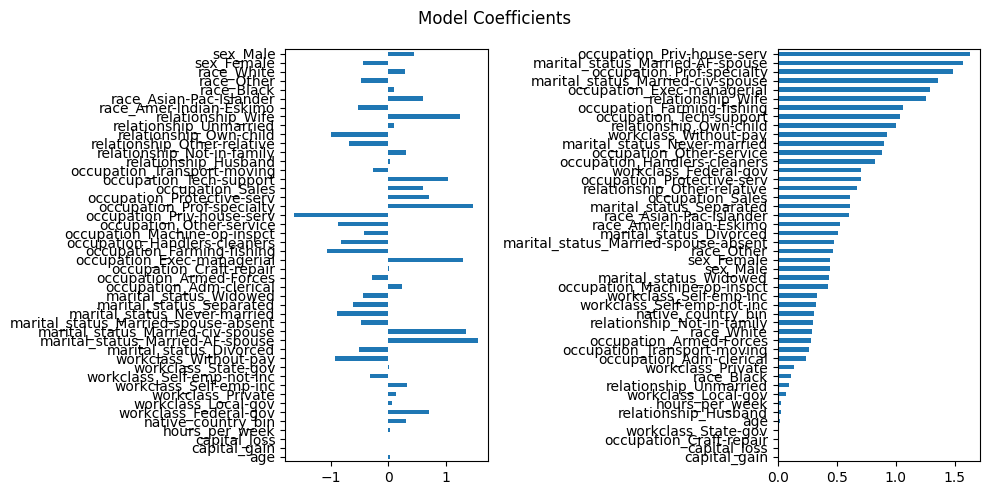

In [160]:
show_coefs(log_model)